### 1 — Imports

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### 2 — Paths

In [3]:
img_path = Path("../data/raw/runway.png")
out_dir = Path("../results/q03")
out_dir.mkdir(parents=True, exist_ok=True)

print("Input path:", img_path.resolve())
print("Output folder:", out_dir.resolve())

Input path: D:\KROCK\UNIVERSITY (DO NOT DELETE)\Masters in AI\1st Year\Y1Q3\CV\Assignment\258839R_IT5437_CV_Assignment_1\data\raw\runway.png
Output folder: D:\KROCK\UNIVERSITY (DO NOT DELETE)\Masters in AI\1st Year\Y1Q3\CV\Assignment\258839R_IT5437_CV_Assignment_1\results\q03


### 3 — Load image

In [4]:
img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

print("Image loaded successfully")
print("Shape:", img.shape)
print("Data type:", img.dtype)

Image loaded successfully
Shape: (769, 765)
Data type: uint8


### 4 — Show original image

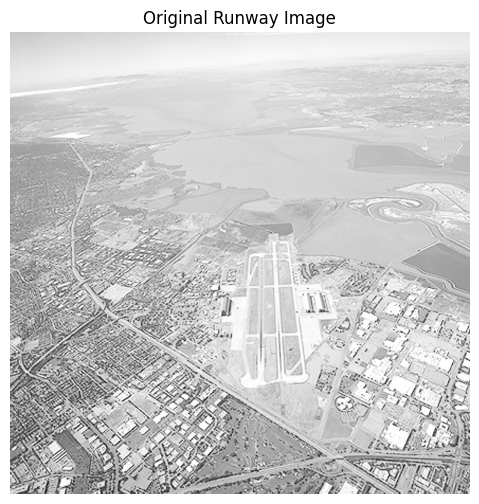

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Runway Image")
plt.axis("off")
plt.show()

### 5 — Manual histogram equalization function

In [6]:
def histogram_equalize(img):
    """
    Perform manual histogram equalization on a grayscale image.
    """
    # Histogram
    hist = np.bincount(img.flatten(), minlength=256)

    # Cumulative distribution function
    cdf = hist.cumsum()

    # First non-zero value in the CDF
    cdf_min = cdf[np.nonzero(cdf)][0]
    total_pixels = img.size

    # Handle constant image case
    if total_pixels == cdf_min:
        return img.copy()

    # Build lookup table
    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    # Map original pixels through LUT
    equalized = lut[img]

    return equalized

### 6 — Apply equalization

In [7]:
eq_img = histogram_equalize(img)
print("Histogram equalization completed.")

Histogram equalization completed.


### 7 — Show original and equalized images

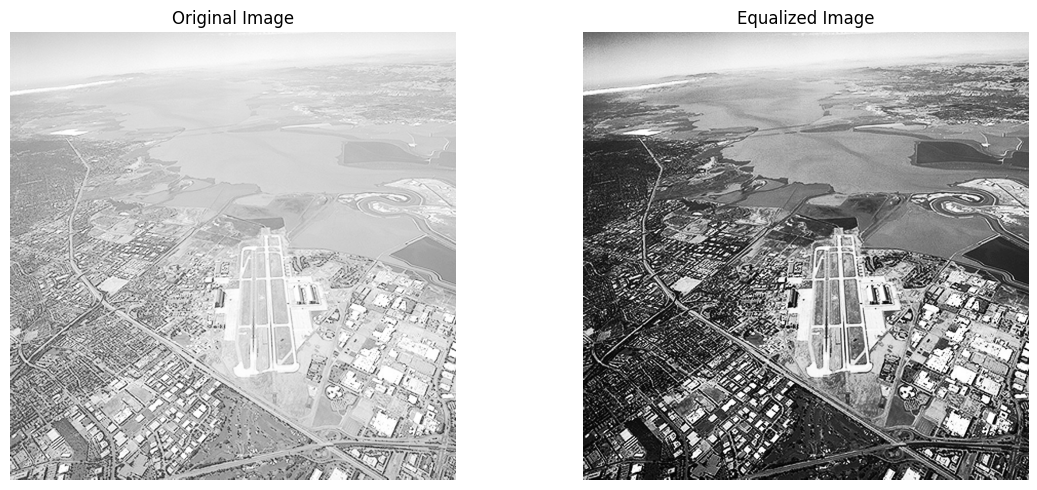

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(eq_img, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

### 8 — Save output

In [9]:
cv2.imwrite(str(out_dir / "runway_equalized.png"), eq_img)
print(f"Saved equalized image to: {out_dir / 'runway_equalized.png'}")

Saved equalized image to: ..\results\q03\runway_equalized.png


### 9 — Plot histograms

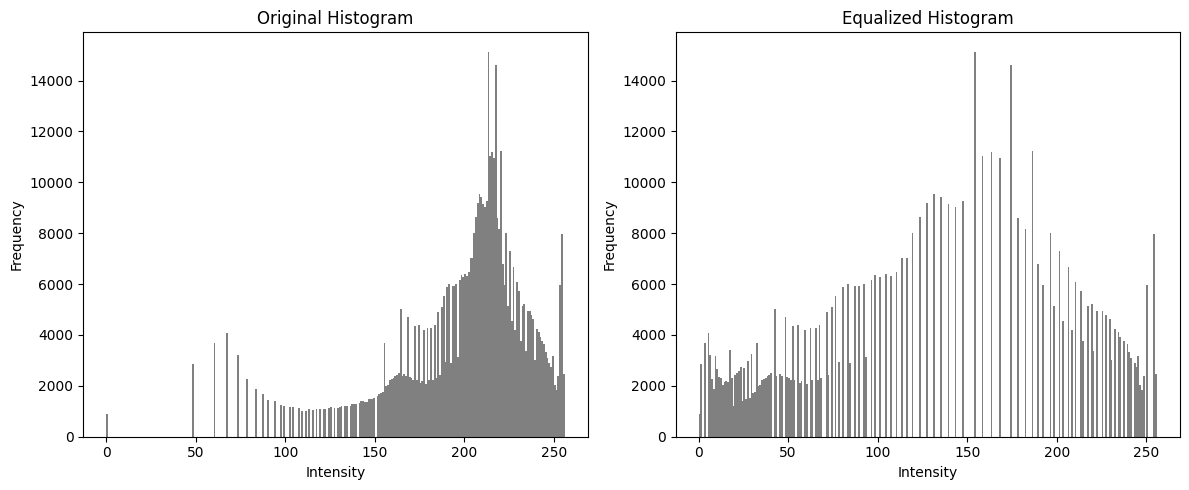

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=[0, 256], color="gray")
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(eq_img.ravel(), bins=256, range=[0, 256], color="gray")
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 10 - Optional comparison with OpenCV

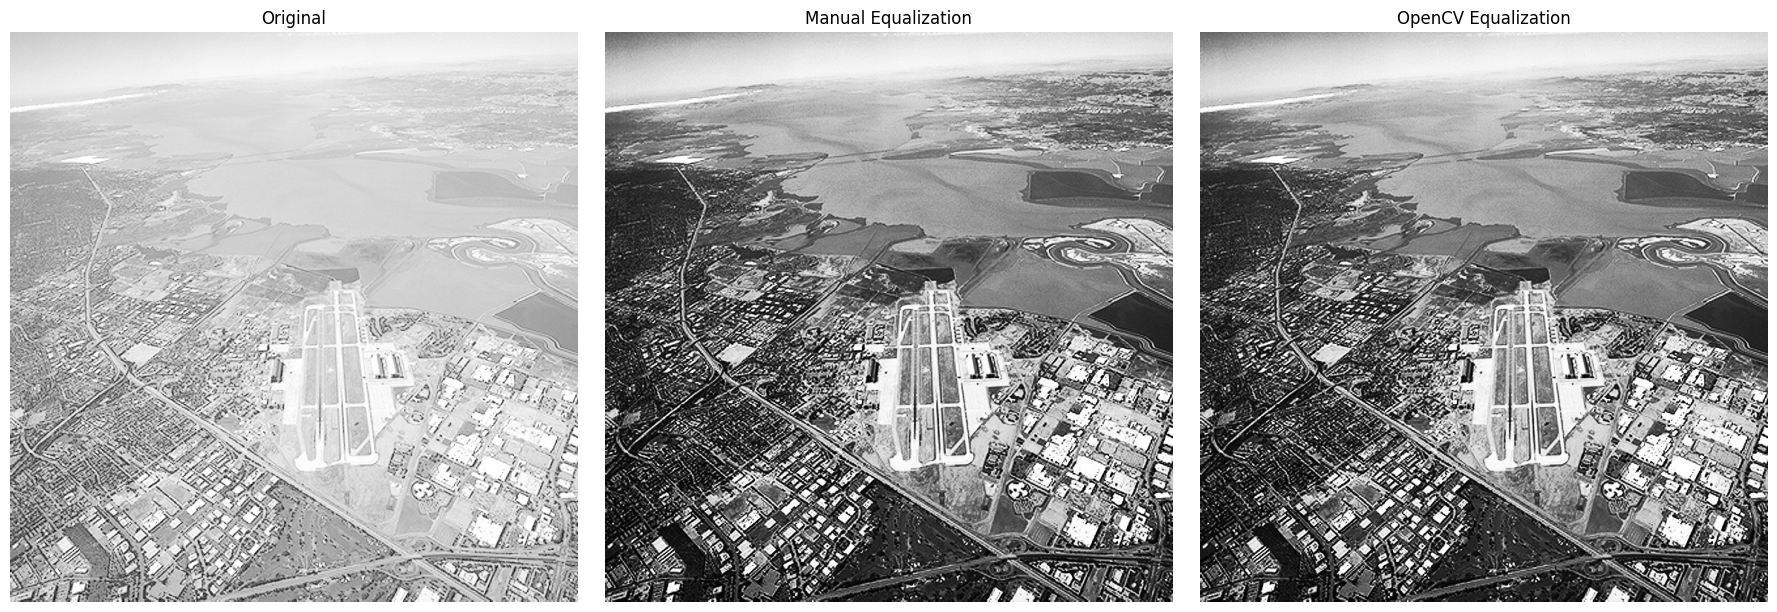

In [11]:
opencv_eq = cv2.equalizeHist(img)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(eq_img, cmap="gray")
plt.title("Manual Equalization")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(opencv_eq, cmap="gray")
plt.title("OpenCV Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()

### 11 - Optional difference check

In [12]:
difference = np.abs(eq_img.astype(np.int16) - opencv_eq.astype(np.int16))

print("Maximum pixel difference:", difference.max())
print("Mean pixel difference:", difference.mean())

Maximum pixel difference: 0
Mean pixel difference: 0.0


## Manual Histogram Equalization

In this question, a custom histogram equalization function was implemented and applied to the runway image.

First, the histogram of the grayscale image was computed. Then, the cumulative distribution function (CDF) was obtained and used to create a lookup table that remaps the original intensity values. The first non-zero CDF value was subtracted to perform proper histogram equalization.

The equalized image shows improved overall contrast. Details such as the runway, roads, buildings, and surrounding structures become more distinguishable compared to the original image. The histogram of the processed image is also more spread out over the available intensity range.